# Exploratory Data Analysis

In [1]:
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np
import plotly.graph_objects as go
import torch

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.data.jet_constituents_data_loading import JetConstL1TriggerDataset
from src.data.event_particles_data_loading import EventPartL1TriggerDataset
from src.data.event_jets_data_loading import EventJetsL1TriggerDataset

Let us start by viewing the features of a generic parquet data file.

In [3]:
file_path = "/run/media/francesco/STORAGE/data_cern_2/Test/minbias/minbias-NEVENT10000-RS59000010.parquet"

parquet_file = pq.read_schema(file_path)

In [4]:
parquet_file.names

['FullReco_PUPPIPart_PT',
 'FullReco_PUPPIPart_Eta',
 'FullReco_PUPPIPart_Phi',
 'FullReco_PUPPIPart_E',
 'FullReco_PUPPIPart_Charge',
 'FullReco_PUPPIPart_Mass',
 'FullReco_PUPPIPart_PID',
 'FullReco_PUPPIPart_D0',
 'FullReco_PUPPIPart_DZ',
 'FullReco_PUPPIPart_ErrorD0',
 'FullReco_PUPPIPart_ErrorDZ',
 'FullReco_PUPPIPart_fUniqueID',
 'FullReco_PUPPIPart_PuppiW',
 'FullReco_PUPPIPart_IsPU',
 'FullReco_PUPPIPart_IsRecoPU',
 'FullReco_PFPart_PT',
 'FullReco_PFPart_Eta',
 'FullReco_PFPart_Phi',
 'FullReco_PFPart_E',
 'FullReco_PFPart_Charge',
 'FullReco_PFPart_Mass',
 'FullReco_PFPart_PID',
 'FullReco_PFPart_D0',
 'FullReco_PFPart_DZ',
 'FullReco_PFPart_ErrorD0',
 'FullReco_PFPart_ErrorDZ',
 'FullReco_PFPart_fUniqueID',
 'FullReco_PFPart_PuppiW',
 'FullReco_PFPart_IsPU',
 'FullReco_PFPart_IsRecoPU',
 'FullReco_Electron_PT',
 'FullReco_Electron_Eta',
 'FullReco_Electron_Phi',
 'FullReco_Electron_Charge',
 'FullReco_Electron_EhadOverEem',
 'FullReco_Electron_IsolationVar',
 'FullReco_Elect

# Original features not preprocessed

We are interested in L1-trigger data, in particular on the kinematic features $p_T$, $\eta$ and $\phi$.

## Jet-constituents-level

### minbias

In [5]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/minbias",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [6]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [15]:
print(f"Total jets: {tot_jets}")

Total jets: 3533


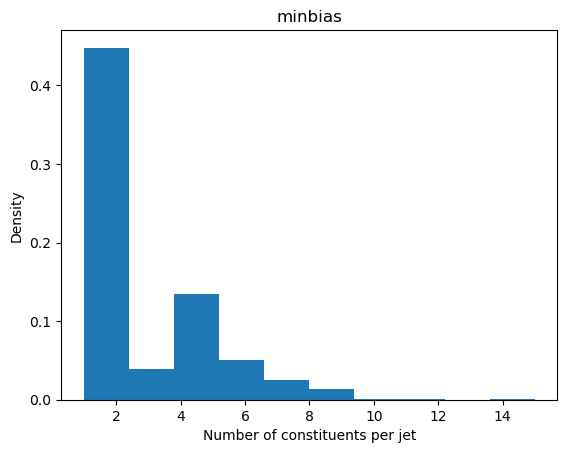

In [16]:
plt.hist(num_const, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("minbias")
plt.show()

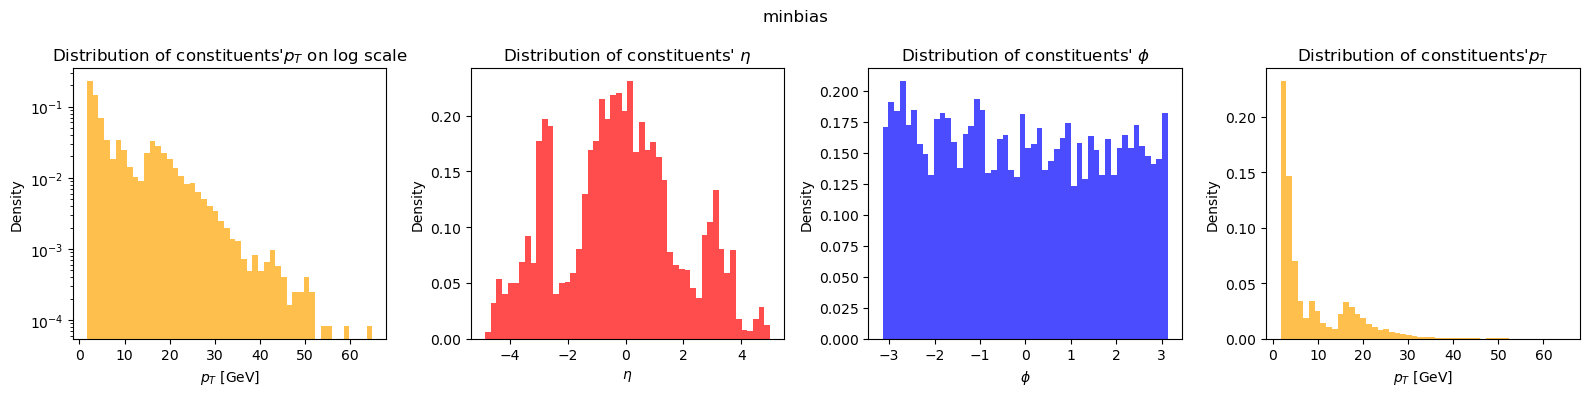

In [17]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of constituents'$p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of constituents' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of constituents' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of constituents'$p_T$")

plt.suptitle("minbias")
plt.tight_layout()
plt.show()

### ggHbb

In [121]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/ggHbb",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [122]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [123]:
print(f"Total jets: {tot_jets}")

Total jets: 56621


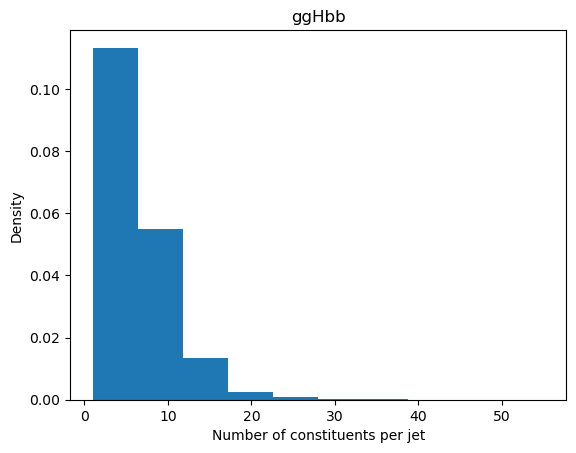

In [124]:
plt.hist(num_const, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("ggHbb")
plt.show()

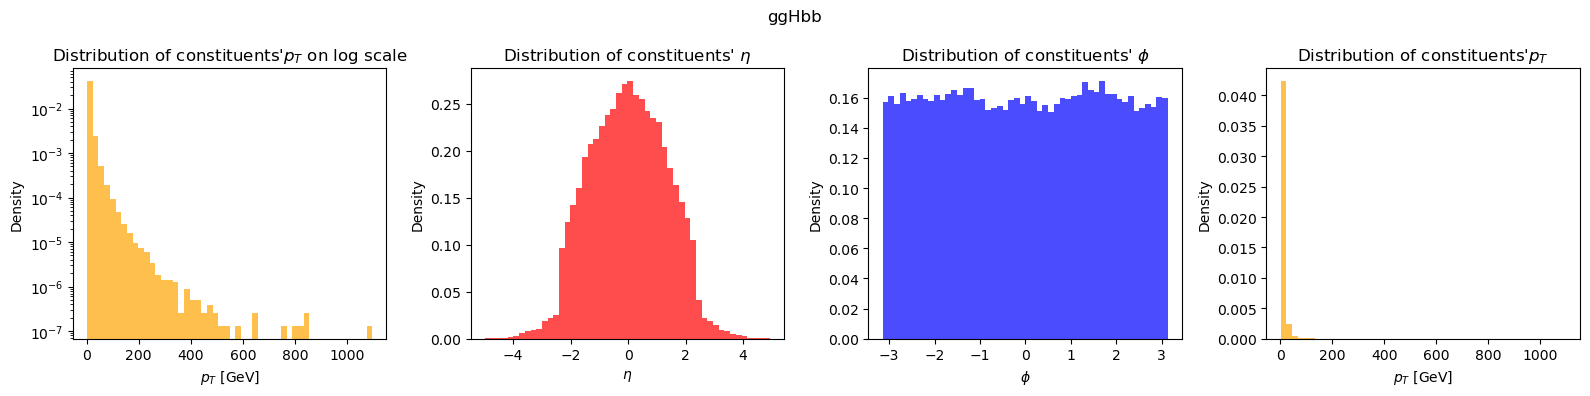

In [125]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of constituents'$p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of constituents' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of constituents' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of constituents'$p_T$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### minbias and ggHbb

In [ ]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=False,
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [24]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [25]:
print(f"Total jets: {tot_jets}")

Total jets: 60154


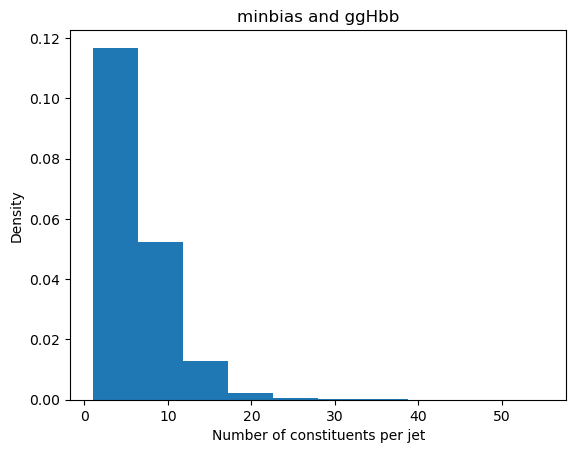

In [26]:
plt.hist(num_const, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("minbias and ggHbb")
plt.show()

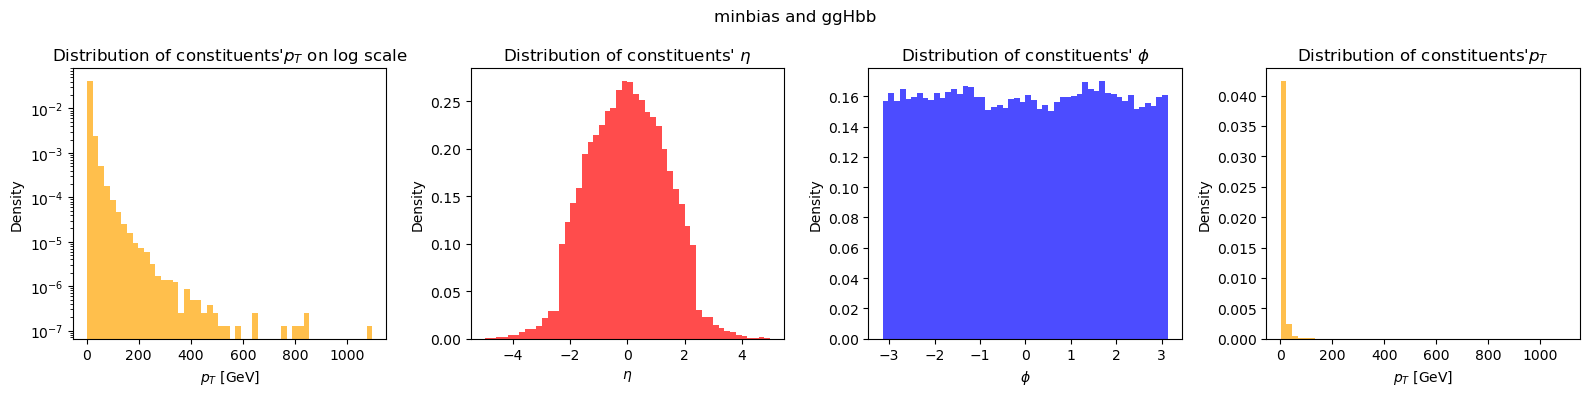

In [27]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of constituents'$p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of constituents' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of constituents' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of constituents'$p_T$")

plt.suptitle("minbias and ggHbb")
plt.tight_layout()
plt.show()

## Event-particles-level

### minbias

In [95]:
# Initialize train dataset
dataset = EventPartL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/minbias",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
        ],
    puppiw_threshold=0.05,
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [96]:
pt = []
eta = []
phi = []
tot_events = 0
num_part = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_part.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [97]:
print(f"Total events: {tot_events}")

Total events: 8034


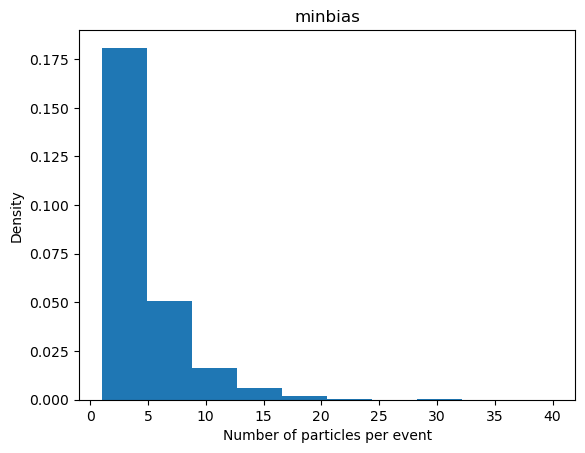

In [98]:
plt.hist(num_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.title("minbias")
plt.show()

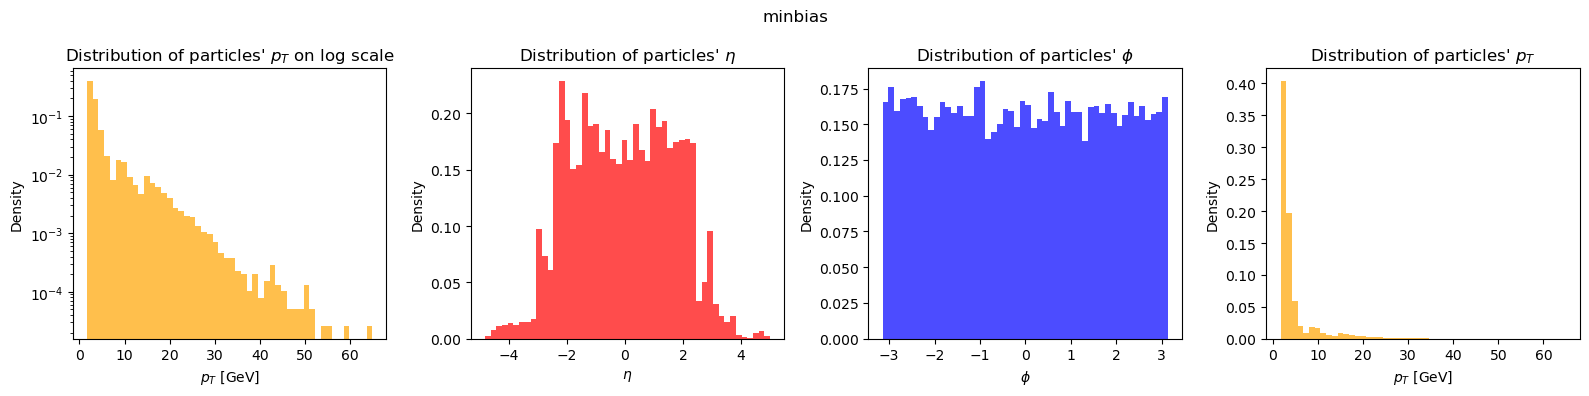

In [101]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of particles' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of particles' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of particles' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of particles' $p_T$")


plt.suptitle("minbias")
plt.tight_layout()
plt.show()

### ggHbb

In [102]:
# Initialize train dataset
dataset = EventPartL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/ggHbb",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
        ],
    puppiw_threshold=0.05,
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [103]:
pt = []
eta = []
phi = []
tot_events = 0
num_part = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_part.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [104]:
print(f"Total events: {tot_events}")

Total events: 14978


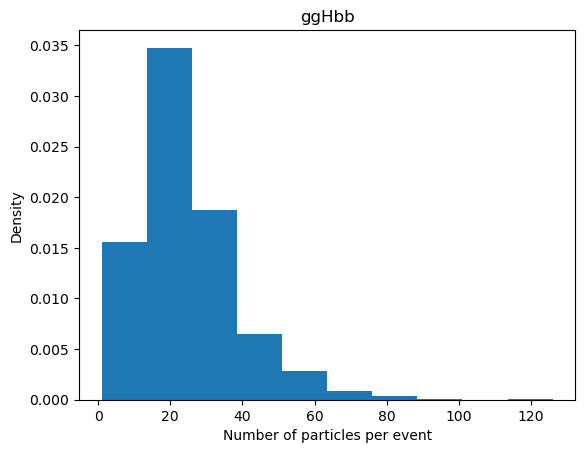

In [106]:
plt.hist(num_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.title("ggHbb")
plt.show()

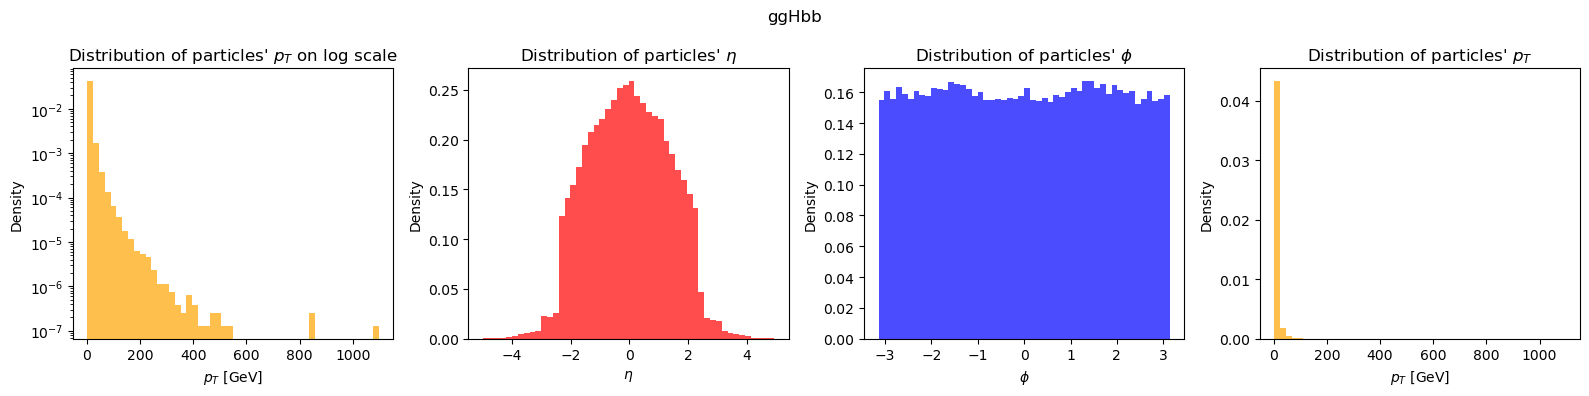

In [109]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of particles' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of particles' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of particles' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of particles' $p_T$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### minbias and ggHbb

In [110]:
# Initialize train dataset
dataset = EventPartL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
        ],
    puppiw_threshold=0.05,
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [111]:
pt = []
eta = []
phi = []
tot_events = 0
num_part = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_part.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [112]:
print(f"Total events: {tot_events}")

Total events: 28011


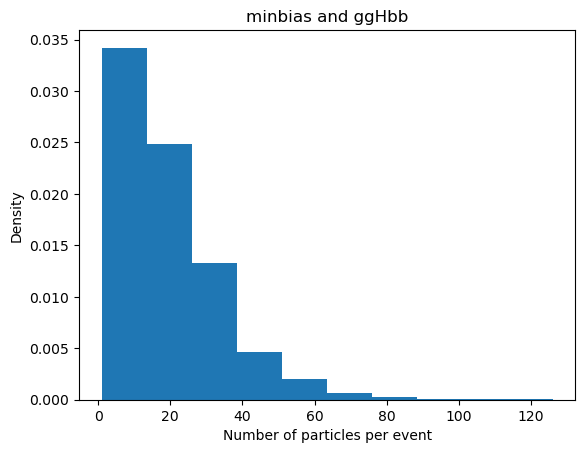

In [113]:
plt.hist(num_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.title("minbias and ggHbb")
plt.show()

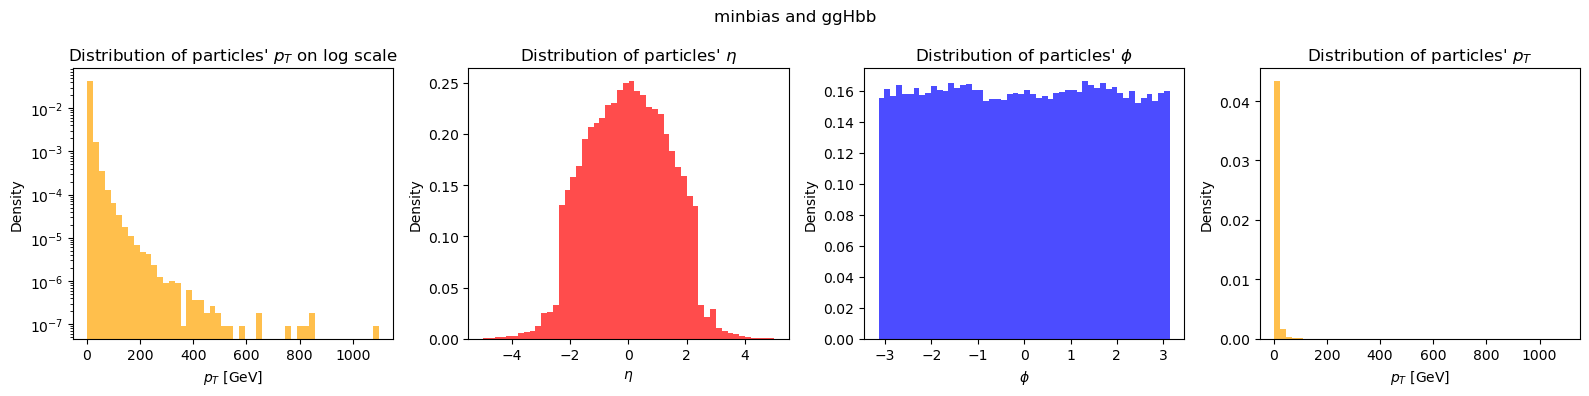

In [114]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of particles' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of particles' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of particles' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of particles' $p_T$")

plt.suptitle("minbias and ggHbb")
plt.tight_layout()
plt.show()

## Event-jets-level

### minbias

In [ ]:
# Initialize train dataset
dataset = EventJetsL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/minbias",
    max_jets=16,
    features=["L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [132]:
pt = []
eta = []
phi = []
tot_events = 0
num_jets = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_jets.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [133]:
print(f"Total events: {tot_events}")

Total events: 3125


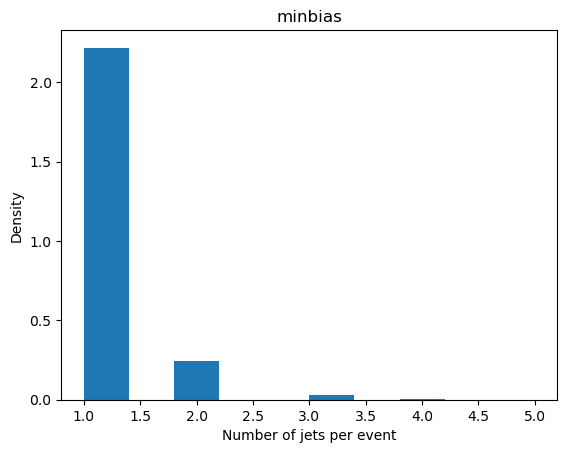

In [135]:
plt.hist(num_jets, density=True)
plt.xlabel("Number of jets per event")
plt.ylabel("Density")
plt.title("minbias")
plt.show()

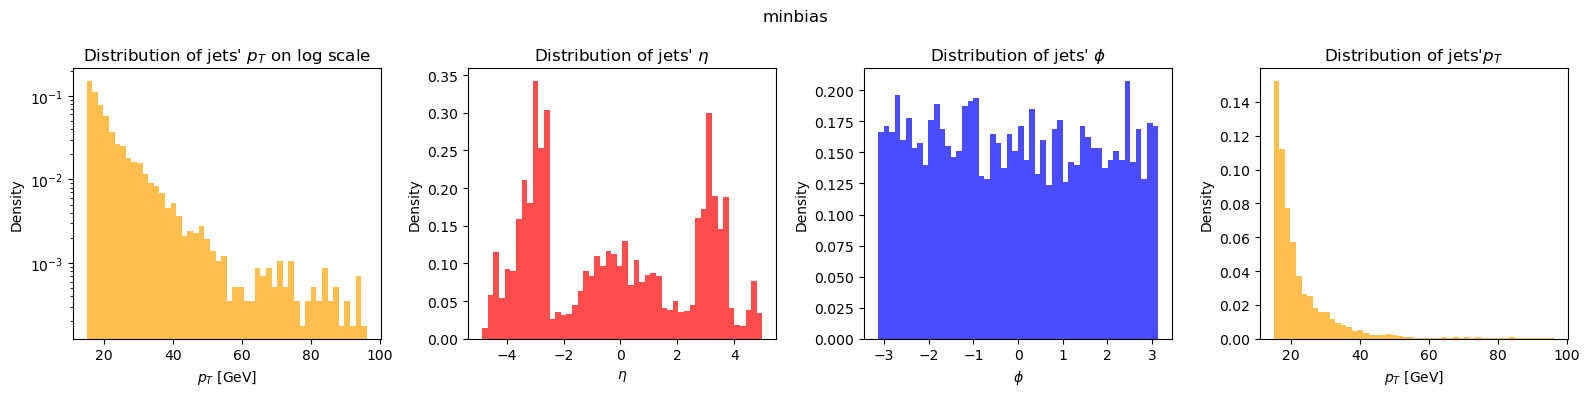

In [136]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of jets' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of jets' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of jets' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of jets'$p_T$")

plt.suptitle("minbias")
plt.tight_layout()
plt.show()

### ggHbb

In [137]:
# Initialize train dataset
dataset = EventJetsL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/ggHbb",
    max_jets=16,
    features=["L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [138]:
pt = []
eta = []
phi = []
tot_events = 0
num_jets = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_jets.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [139]:
print(f"Total events: {tot_events}")

Total events: 19416


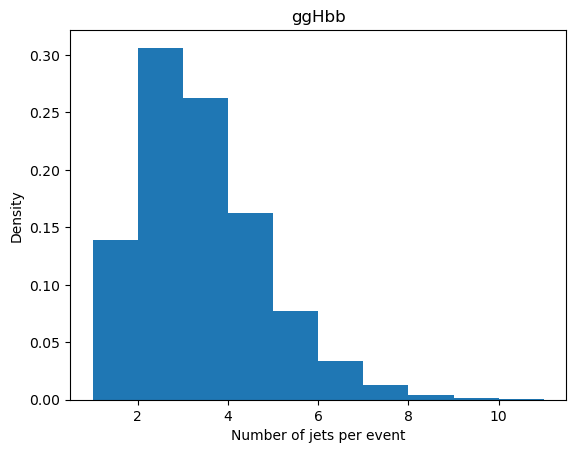

In [140]:
plt.hist(num_jets, density=True)
plt.xlabel("Number of jets per event")
plt.ylabel("Density")
plt.title("ggHbb")
plt.show()

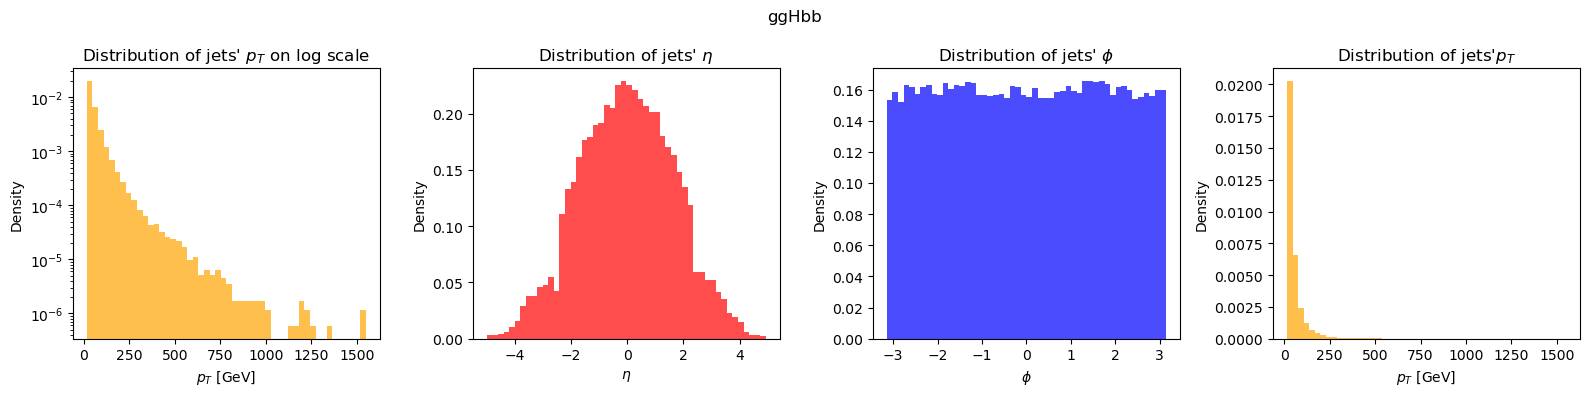

In [141]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of jets' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of jets' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of jets' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of jets'$p_T$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### minbias and ggHbb

In [ ]:
# Initialize train dataset
dataset = EventJetsL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val",
    max_jets=16,
    features=["L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
        ],
    preprocessing=False,
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [143]:
pt = []
eta = []
phi = []
tot_events = 0
num_jets = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_jets.extend(m.sum(axis=1))

    tot_events += x.shape[0]

In [144]:
print(f"Total events: {tot_events}")

Total events: 22541


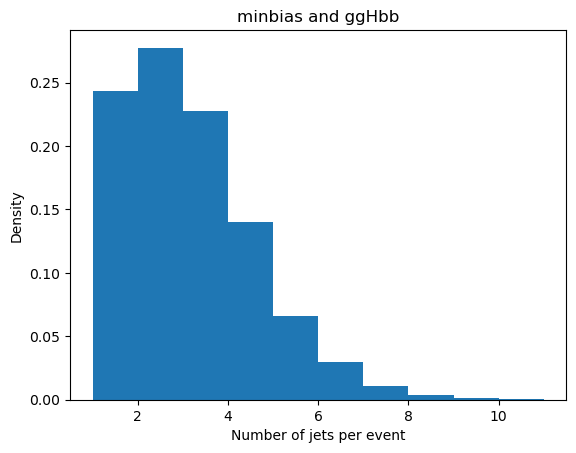

In [145]:
plt.hist(num_jets, density=True)
plt.xlabel("Number of jets per event")
plt.ylabel("Density")
plt.title("minbias and ggHbb")
plt.show()

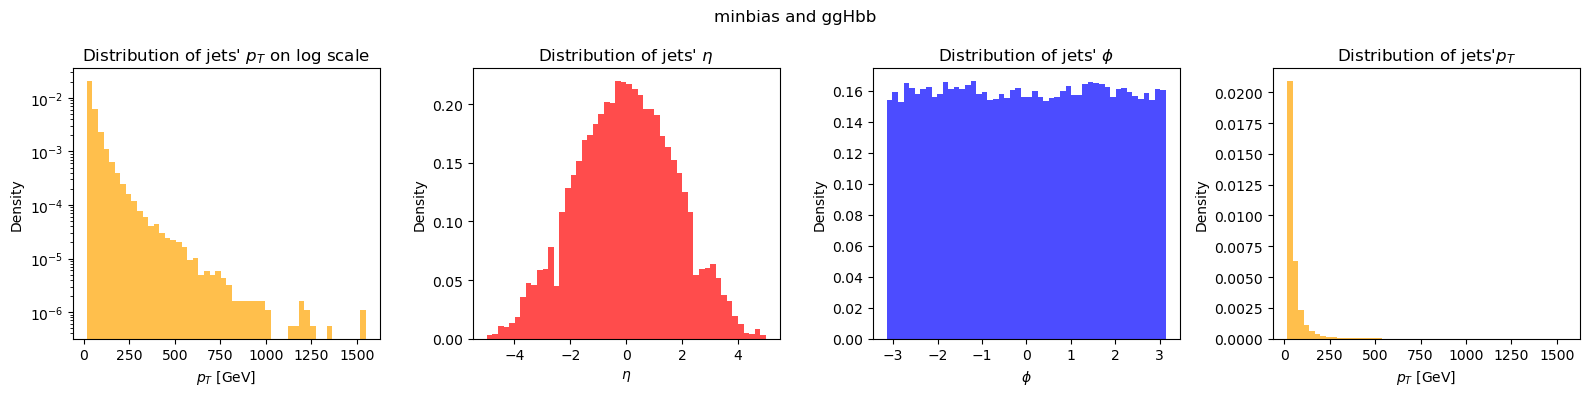

In [146]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of jets' $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of jets' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of jets' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of jets'$p_T$")

plt.suptitle("minbias and ggHbb")
plt.tight_layout()
plt.show()

# Original features preprocessed

## Jet-constituents-level

### minbias

In [50]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/minbias",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=True
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [51]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [52]:
print(f"Total jets: {tot_jets}")

Total jets: 3533


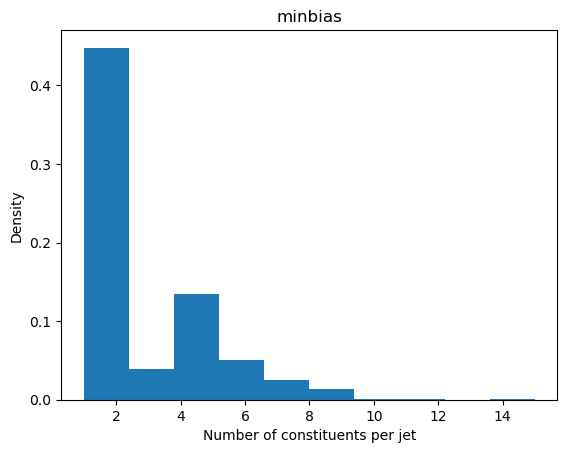

In [53]:
plt.hist(num_const, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("minbias")
plt.show()

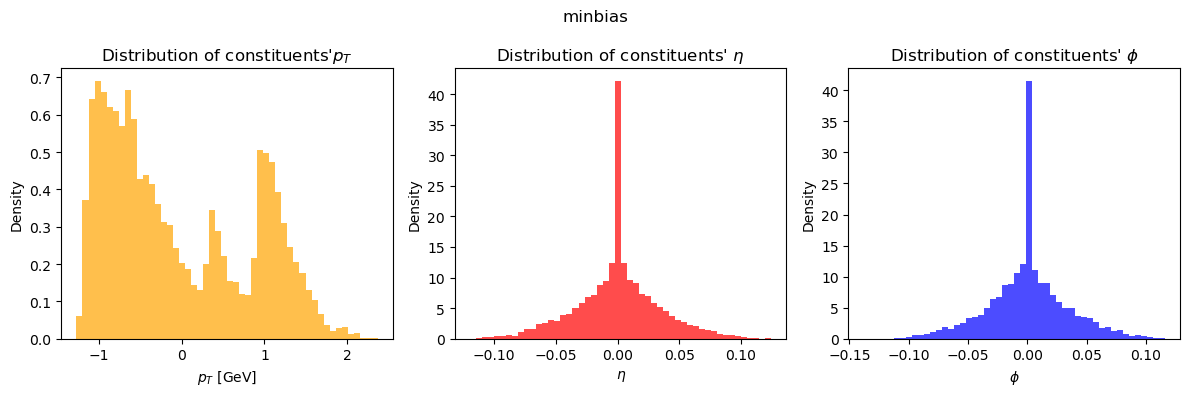

In [54]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of constituents'$p_T$")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of constituents' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of constituents' $\phi$")

plt.suptitle("minbias")
plt.tight_layout()
plt.show()

### ggHbb

In [55]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/ggHbb",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=True
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [56]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [57]:
print(f"Total jets: {tot_jets}")

Total jets: 56621


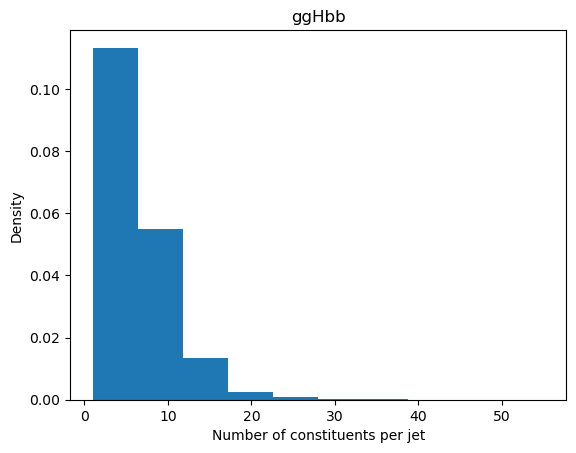

In [58]:
plt.hist(num_const, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("ggHbb")
plt.show()

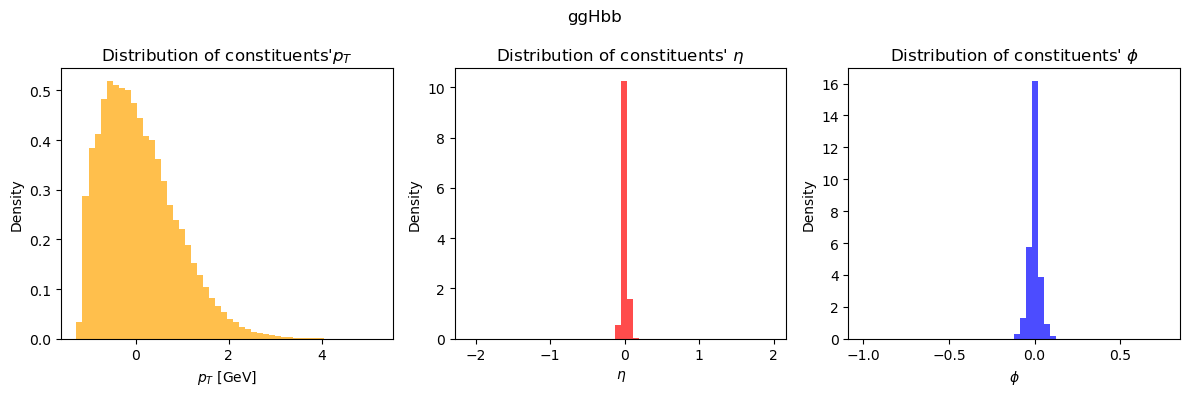

In [59]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of constituents'$p_T$")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of constituents' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of constituents' $\phi$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### minbias and ggHbb

In [153]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=True
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [154]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [155]:
print(f"Total jets: {tot_jets}")

Total jets: 60154


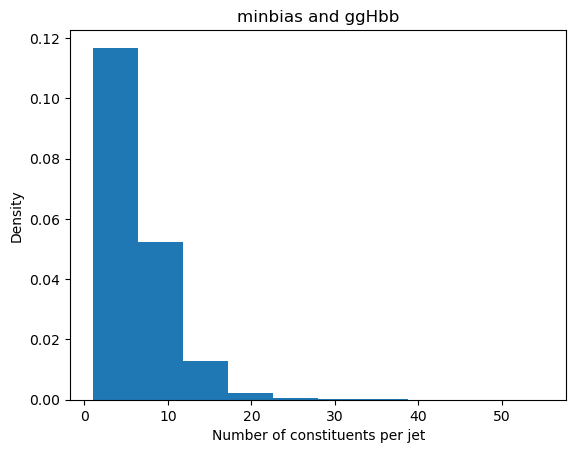

In [63]:
plt.hist(num_const, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("minbias and ggHbb")
plt.show()

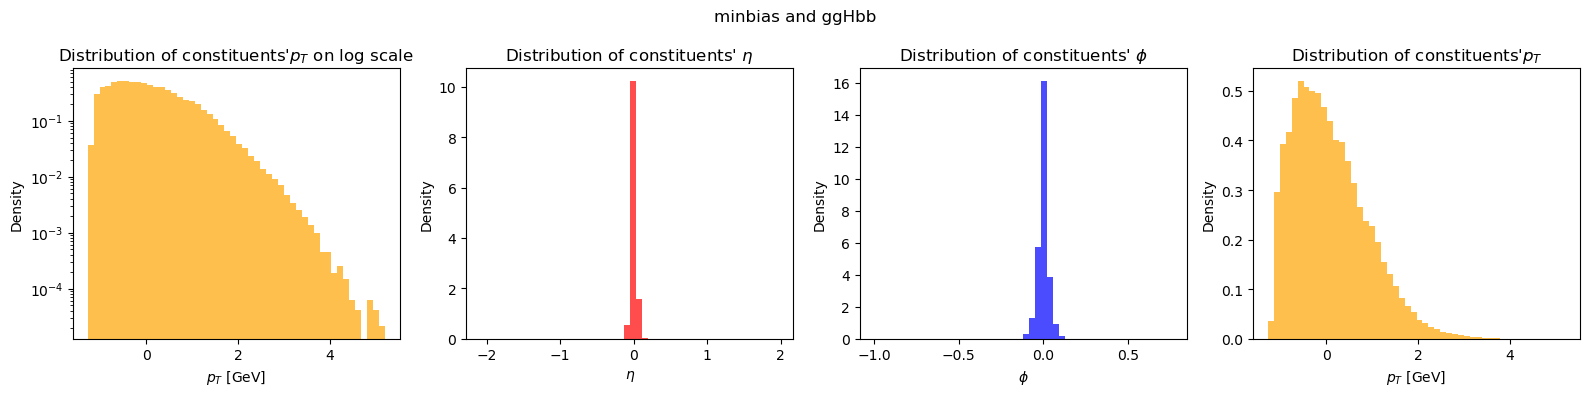

In [157]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of constituents'$p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of constituents' $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of constituents' $\phi$")

ax[3].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[3].set_xlabel(r"$p_T$ [GeV]")
ax[3].set_ylabel("Density")
ax[3].set_title(r"Distribution of constituents'$p_T$")

plt.suptitle("minbias and ggHbb")
plt.tight_layout()
plt.show()

## Event-particles-level

### minbias

In [65]:
# Initialize train dataset
dataset = EventPartL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/minbias",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
        ],
    puppiw_threshold=0.05,
    preprocessing=True
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [66]:
pt = []
eta = []
phi = []
phi_sin = []
phi_cos = []
tot_events = 0
num_part = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi_sin.extend(x[:, :, 2][m])
    phi_cos.extend(x[:, :, 3][m])
    phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))

    num_part.extend(m.sum(axis=1))

    tot_events += x.shape[0]

/tmp/ipykernel_21148/642062865.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/642062865.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))


In [67]:
print(f"Total events: {tot_events}")

Total events: 8034


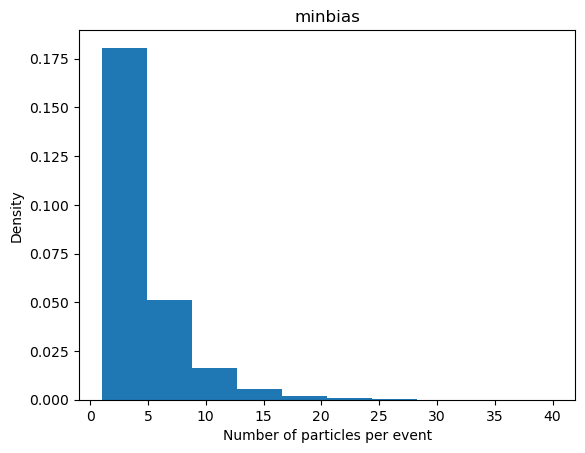

In [68]:
plt.hist(num_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.title("minbias")
plt.show()

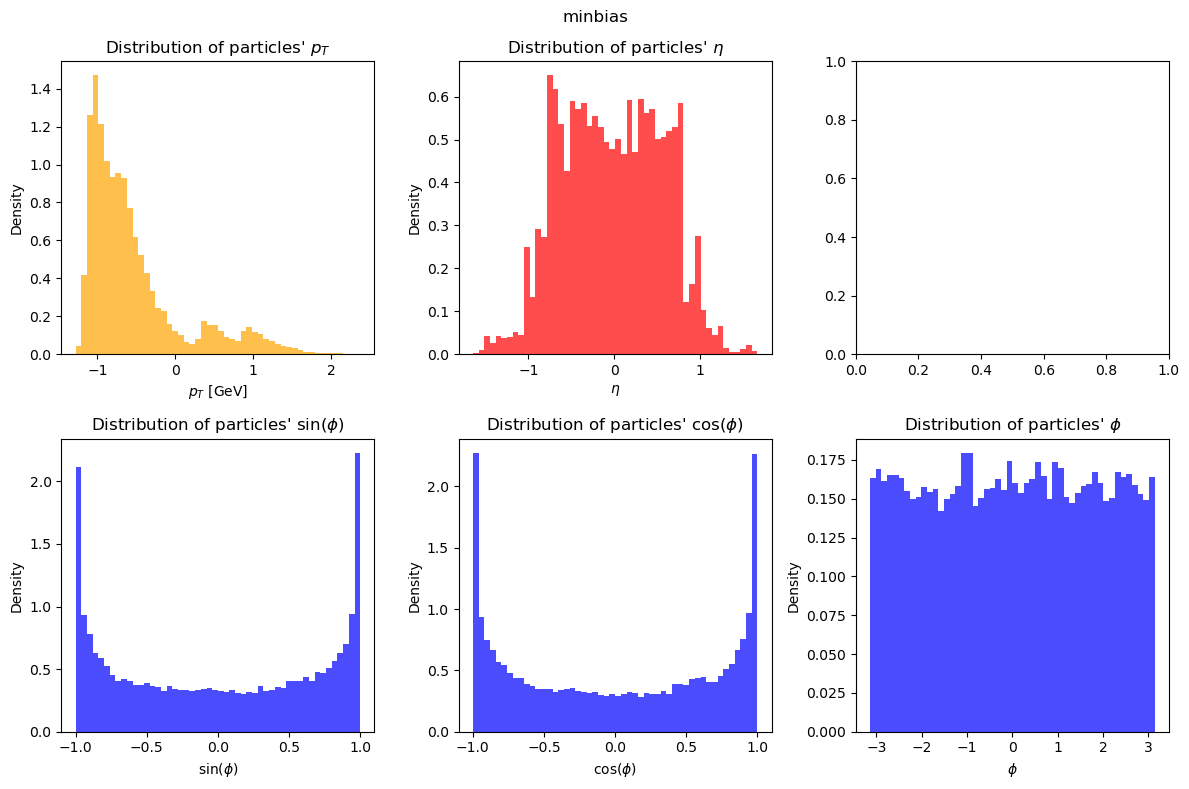

In [69]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

ax[0,0].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0,0].set_xlabel(r"$p_T$ [GeV]")
ax[0,0].set_ylabel("Density")
ax[0,0].set_title(r"Distribution of particles' $p_T$")

ax[0,1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[0,1].set_xlabel(r"$\eta$")
ax[0,1].set_ylabel("Density")
ax[0,1].set_title(r"Distribution of particles' $\eta$")

ax[1,0].hist(phi_sin, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,0].set_xlabel(r"$\sin(\phi)$")
ax[1,0].set_ylabel("Density")
ax[1,0].set_title(r"Distribution of particles' $\sin(\phi)$")

ax[1,1].hist(phi_cos, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,1].set_xlabel(r"$\cos(\phi)$")
ax[1,1].set_ylabel("Density")
ax[1,1].set_title(r"Distribution of particles' $\cos(\phi)$")

ax[1,2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,2].set_xlabel(r"$\phi$")
ax[1,2].set_ylabel("Density")
ax[1,2].set_title(r"Distribution of particles' $\phi$")

plt.suptitle("minbias")
plt.tight_layout()
plt.show()

### ggHbb

In [70]:
# Initialize train dataset
dataset = EventPartL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/ggHbb",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
        ],
    puppiw_threshold=0.05,
    preprocessing=True
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [71]:
pt = []
eta = []
phi = []
phi_sin = []
phi_cos = []
tot_events = 0
num_part = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi_sin.extend(x[:, :, 2][m])
    phi_cos.extend(x[:, :, 3][m])
    phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))

    num_part.extend(m.sum(axis=1))

    tot_events += x.shape[0]

/tmp/ipykernel_21148/642062865.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/642062865.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))


In [72]:
print(f"Total events: {tot_events}")

Total events: 14978


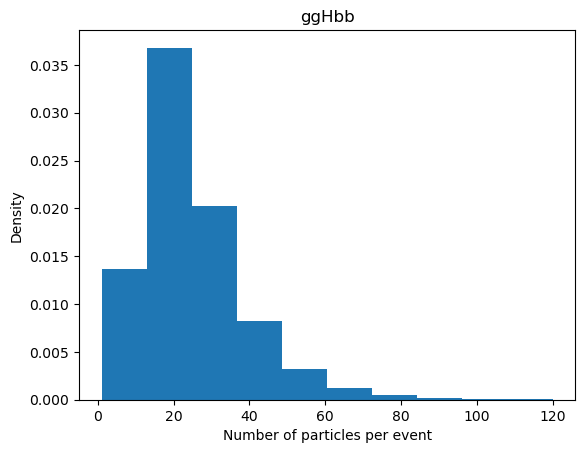

In [73]:
plt.hist(num_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.title("ggHbb")
plt.show()

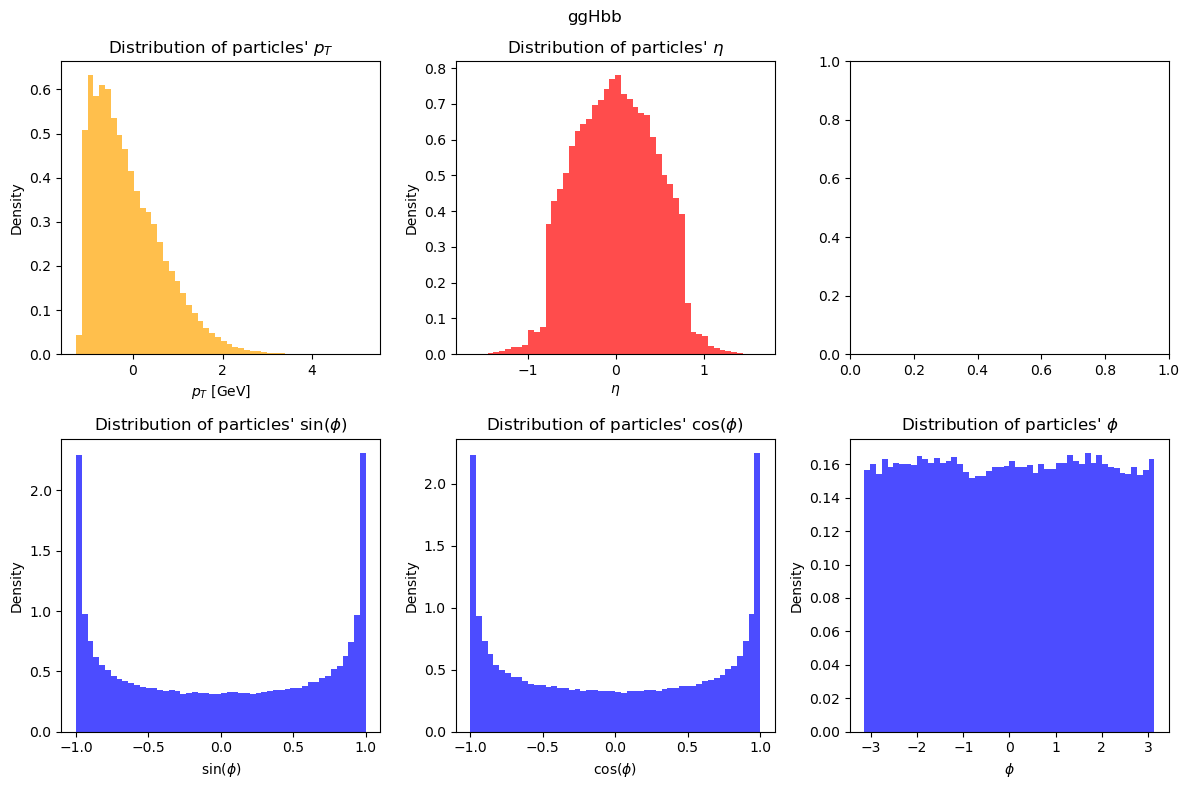

In [74]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

ax[0,0].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0,0].set_xlabel(r"$p_T$ [GeV]")
ax[0,0].set_ylabel("Density")
ax[0,0].set_title(r"Distribution of particles' $p_T$")

ax[0,1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[0,1].set_xlabel(r"$\eta$")
ax[0,1].set_ylabel("Density")
ax[0,1].set_title(r"Distribution of particles' $\eta$")

ax[1,0].hist(phi_sin, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,0].set_xlabel(r"$\sin(\phi)$")
ax[1,0].set_ylabel("Density")
ax[1,0].set_title(r"Distribution of particles' $\sin(\phi)$")

ax[1,1].hist(phi_cos, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,1].set_xlabel(r"$\cos(\phi)$")
ax[1,1].set_ylabel("Density")
ax[1,1].set_title(r"Distribution of particles' $\cos(\phi)$")

ax[1,2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,2].set_xlabel(r"$\phi$")
ax[1,2].set_ylabel("Density")
ax[1,2].set_title(r"Distribution of particles' $\phi$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### minbias and ggHbb

In [147]:
# Initialize train dataset
dataset = EventPartL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
        ],
    puppiw_threshold=0.05,
    preprocessing=True
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [148]:
pt = []
eta = []
phi = []
phi_sin = []
phi_cos = []
tot_events = 0
num_part = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi_sin.extend(x[:, :, 2][m])
    phi_cos.extend(x[:, :, 3][m])
    phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))

    num_part.extend(m.sum(axis=1))

    tot_events += x.shape[0]

/tmp/ipykernel_21148/642062865.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/642062865.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/642062865.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/642062865.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))


In [149]:
print(f"Total events: {tot_events}")

Total events: 28011


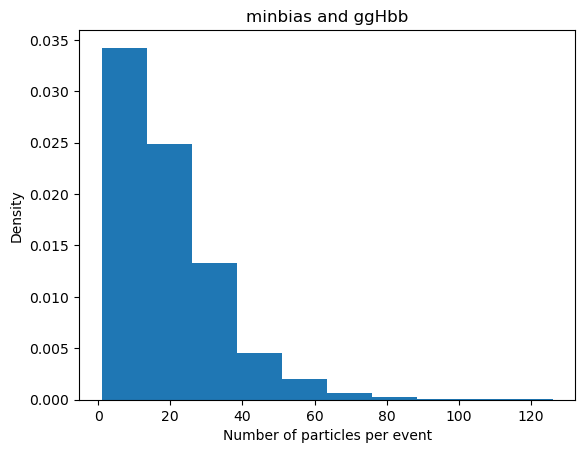

In [150]:
plt.hist(num_part, density=True)
plt.xlabel("Number of particles per event")
plt.ylabel("Density")
plt.title("minbias and ggHbb")
plt.show()

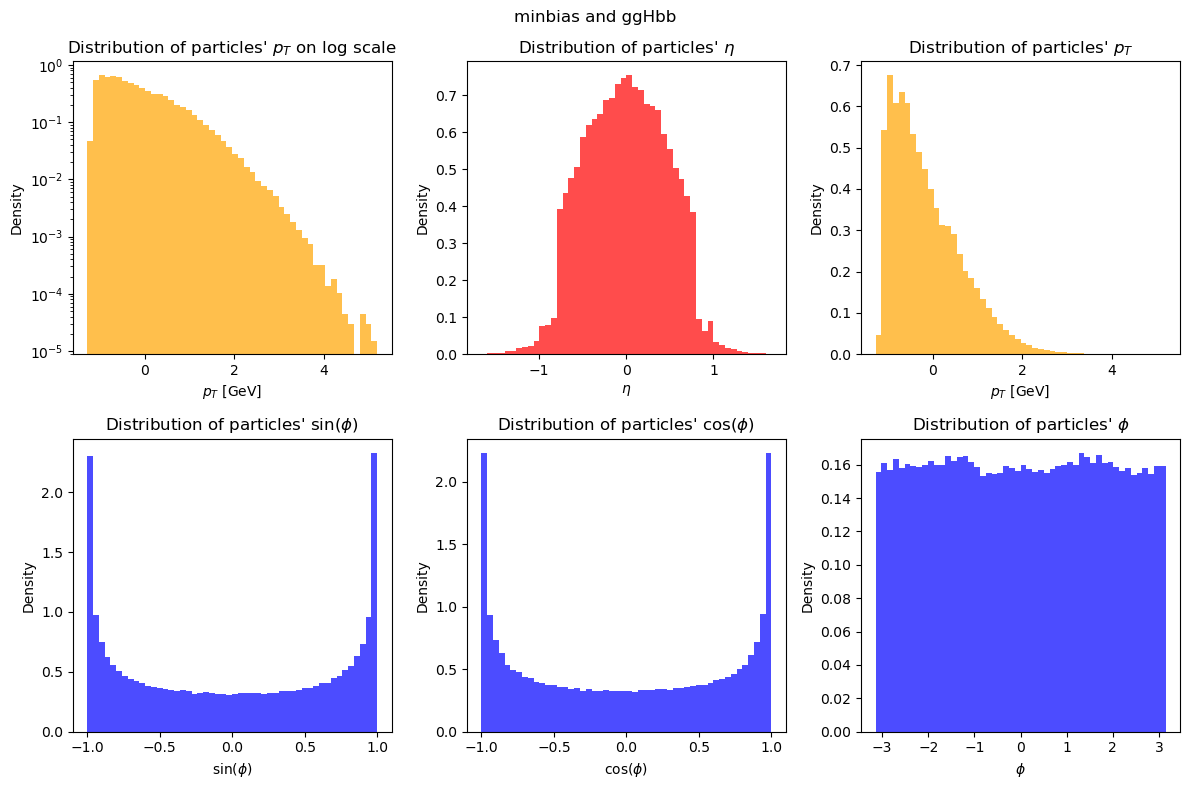

In [152]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

ax[0,0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0,0].set_xlabel(r"$p_T$ [GeV]")
ax[0,0].set_ylabel("Density")
ax[0,0].set_title(r"Distribution of particles' $p_T$ on log scale")

ax[0,1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[0,1].set_xlabel(r"$\eta$")
ax[0,1].set_ylabel("Density")
ax[0,1].set_title(r"Distribution of particles' $\eta$")

ax[0,2].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0,2].set_xlabel(r"$p_T$ [GeV]")
ax[0,2].set_ylabel("Density")
ax[0,2].set_title(r"Distribution of particles' $p_T$")

ax[1,0].hist(phi_sin, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,0].set_xlabel(r"$\sin(\phi)$")
ax[1,0].set_ylabel("Density")
ax[1,0].set_title(r"Distribution of particles' $\sin(\phi)$")

ax[1,1].hist(phi_cos, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,1].set_xlabel(r"$\cos(\phi)$")
ax[1,1].set_ylabel("Density")
ax[1,1].set_title(r"Distribution of particles' $\cos(\phi)$")

ax[1,2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,2].set_xlabel(r"$\phi$")
ax[1,2].set_ylabel("Density")
ax[1,2].set_title(r"Distribution of particles' $\phi$")

plt.suptitle("minbias and ggHbb")
plt.tight_layout()
plt.show()

## Event-jets-level

### minbias

In [80]:
# Initialize train dataset
dataset = EventJetsL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/minbias",
    max_jets=16,
    features=["L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
        ],
    preprocessing=True
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [81]:
pt = []
eta = []
phi = []
phi_sin = []
phi_cos = []
tot_events = 0
num_jets = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi_sin.extend(x[:, :, 2][m])
    phi_cos.extend(x[:, :, 3][m])
    phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))

    num_jets.extend(m.sum(axis=1))

    tot_events += x.shape[0]

/tmp/ipykernel_21148/2301269430.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/2301269430.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))


In [82]:
print(f"Total events: {tot_events}")

Total events: 3125


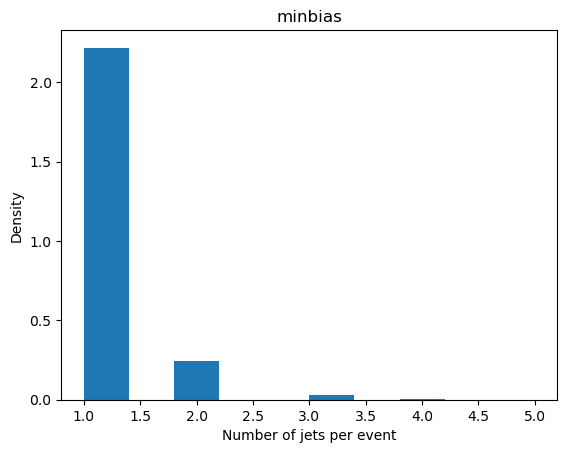

In [83]:
plt.hist(num_jets, density=True)
plt.xlabel("Number of jets per event")
plt.ylabel("Density")
plt.title("minbias")
plt.show()

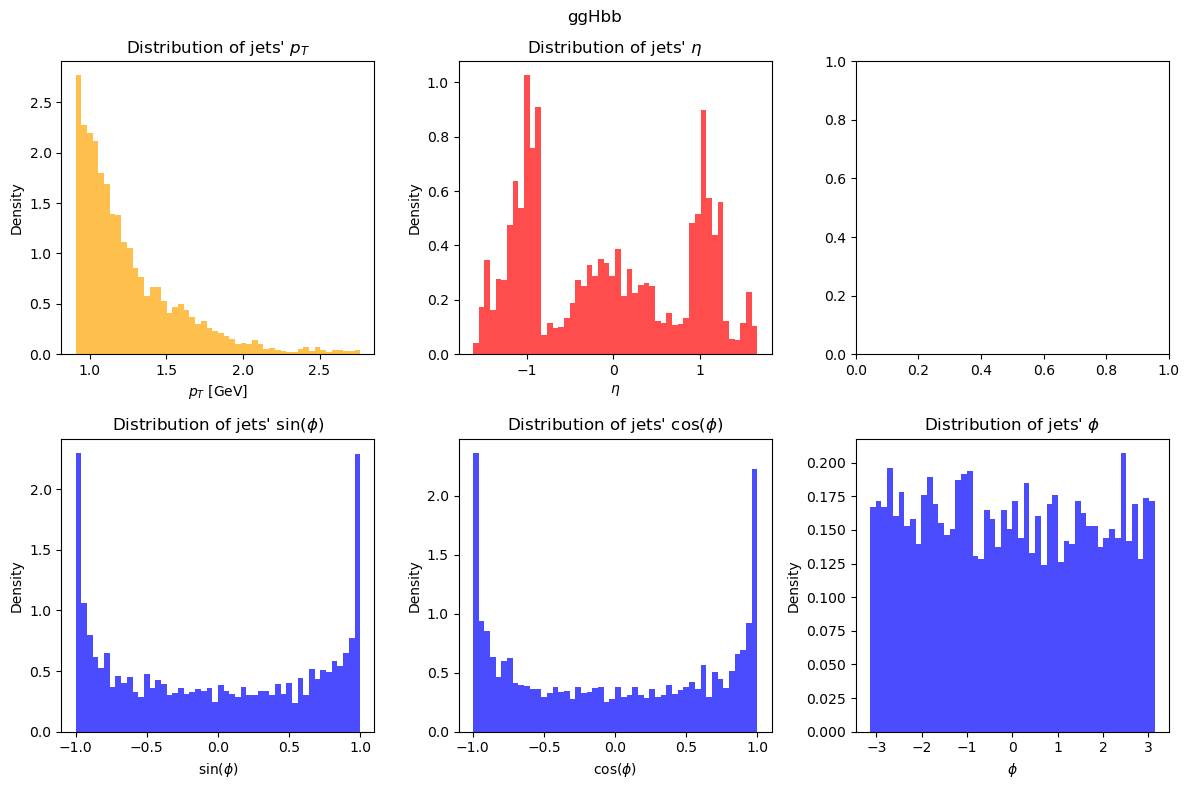

In [84]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

ax[0,0].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0,0].set_xlabel(r"$p_T$ [GeV]")
ax[0,0].set_ylabel("Density")
ax[0,0].set_title(r"Distribution of jets' $p_T$")

ax[0,1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[0,1].set_xlabel(r"$\eta$")
ax[0,1].set_ylabel("Density")
ax[0,1].set_title(r"Distribution of jets' $\eta$")

ax[1,0].hist(phi_sin, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,0].set_xlabel(r"$\sin(\phi)$")
ax[1,0].set_ylabel("Density")
ax[1,0].set_title(r"Distribution of jets' $\sin(\phi)$")

ax[1,1].hist(phi_cos, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,1].set_xlabel(r"$\cos(\phi)$")
ax[1,1].set_ylabel("Density")
ax[1,1].set_title(r"Distribution of jets' $\cos(\phi)$")

ax[1,2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,2].set_xlabel(r"$\phi$")
ax[1,2].set_ylabel("Density")
ax[1,2].set_title(r"Distribution of jets' $\phi$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### ggHbb

In [85]:
# Initialize train dataset
dataset = EventJetsL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val/ggHbb",
    max_jets=16,
    features=["L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
        ],
    preprocessing=True
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [86]:
pt = []
eta = []
phi = []
phi_sin = []
phi_cos = []
tot_events = 0
num_jets = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi_sin.extend(x[:, :, 2][m])
    phi_cos.extend(x[:, :, 3][m])
    phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))

    num_jets.extend(m.sum(axis=1))

    tot_events += x.shape[0]

/tmp/ipykernel_21148/2301269430.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/2301269430.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))


In [87]:
print(f"Total events: {tot_events}")

Total events: 19416


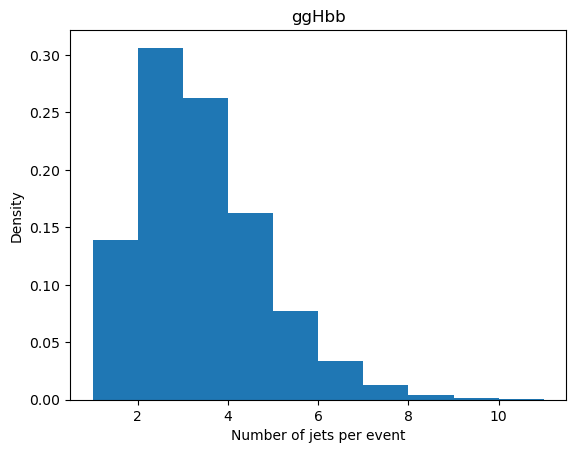

In [88]:
plt.hist(num_jets, density=True)
plt.xlabel("Number of jets per event")
plt.ylabel("Density")
plt.title("ggHbb")
plt.show()

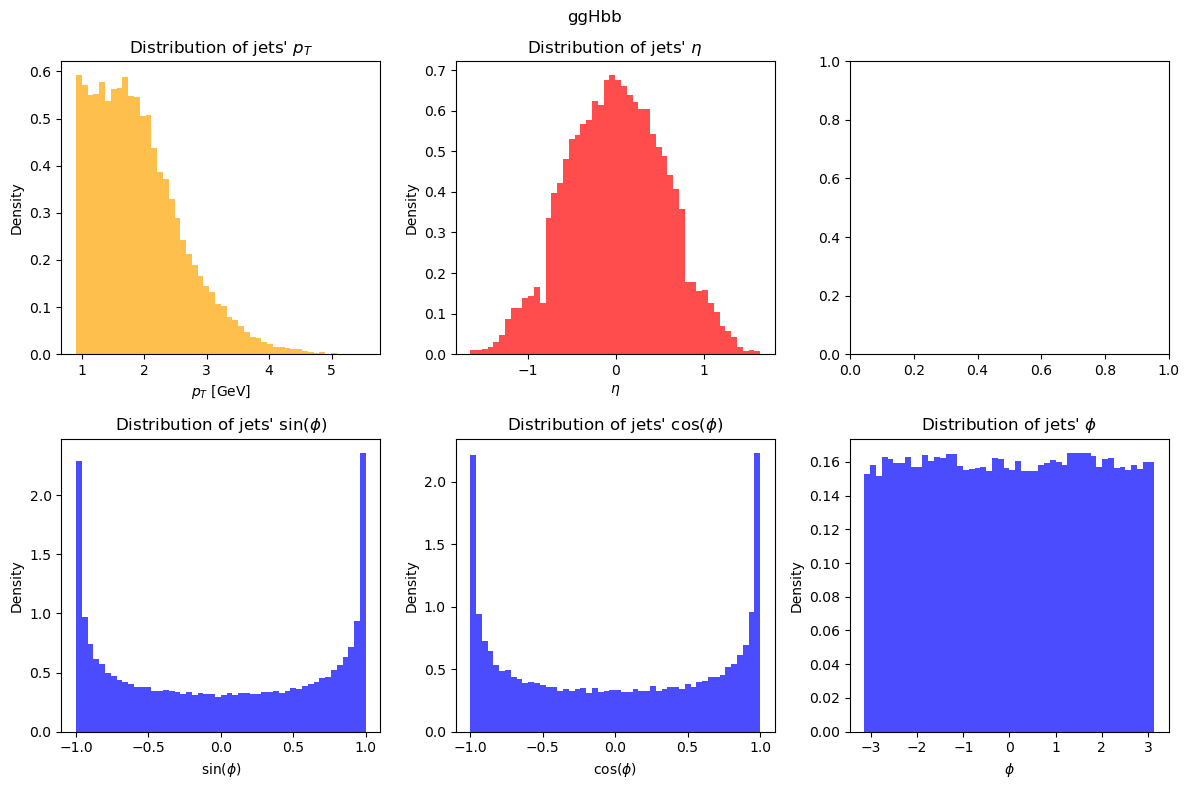

In [89]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

ax[0,0].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0,0].set_xlabel(r"$p_T$ [GeV]")
ax[0,0].set_ylabel("Density")
ax[0,0].set_title(r"Distribution of jets' $p_T$")

ax[0,1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[0,1].set_xlabel(r"$\eta$")
ax[0,1].set_ylabel("Density")
ax[0,1].set_title(r"Distribution of jets' $\eta$")

ax[1,0].hist(phi_sin, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,0].set_xlabel(r"$\sin(\phi)$")
ax[1,0].set_ylabel("Density")
ax[1,0].set_title(r"Distribution of jets' $\sin(\phi)$")

ax[1,1].hist(phi_cos, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,1].set_xlabel(r"$\cos(\phi)$")
ax[1,1].set_ylabel("Density")
ax[1,1].set_title(r"Distribution of jets' $\cos(\phi)$")

ax[1,2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,2].set_xlabel(r"$\phi$")
ax[1,2].set_ylabel("Density")
ax[1,2].set_title(r"Distribution of jets' $\phi$")

plt.suptitle("ggHbb")
plt.tight_layout()
plt.show()

### minbias and ggHbb

In [158]:
# Initialize train dataset
dataset = EventJetsL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern_2/Val",
    max_jets=16,
    features=["L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
        ],
    preprocessing=True
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [159]:
pt = []
eta = []
phi = []
phi_sin = []
phi_cos = []
tot_events = 0
num_jets = []

for x, m in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi_sin.extend(x[:, :, 2][m])
    phi_cos.extend(x[:, :, 3][m])
    phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))

    num_jets.extend(m.sum(axis=1))

    tot_events += x.shape[0]

/tmp/ipykernel_21148/2301269430.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/2301269430.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/2301269430.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))
/tmp/ipykernel_21148/2301269430.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi.extend(np.arctan2(x[:, :, 2][m], x[:, :, 3][m]))


In [92]:
print(f"Total events: {tot_events}")

Total events: 22541


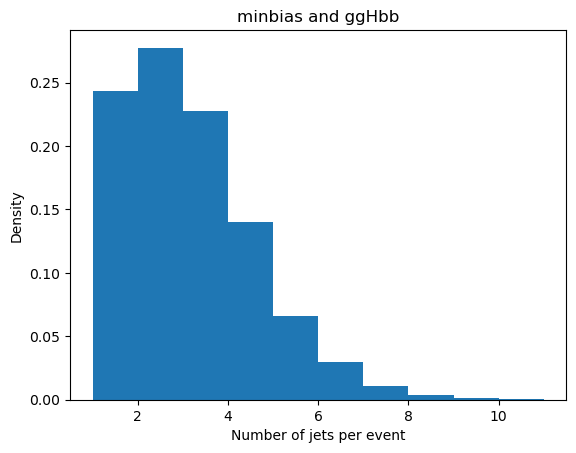

In [93]:
plt.hist(num_jets, density=True)
plt.xlabel("Number of jets per event")
plt.ylabel("Density")
plt.title("minbias and ggHbb")
plt.show()

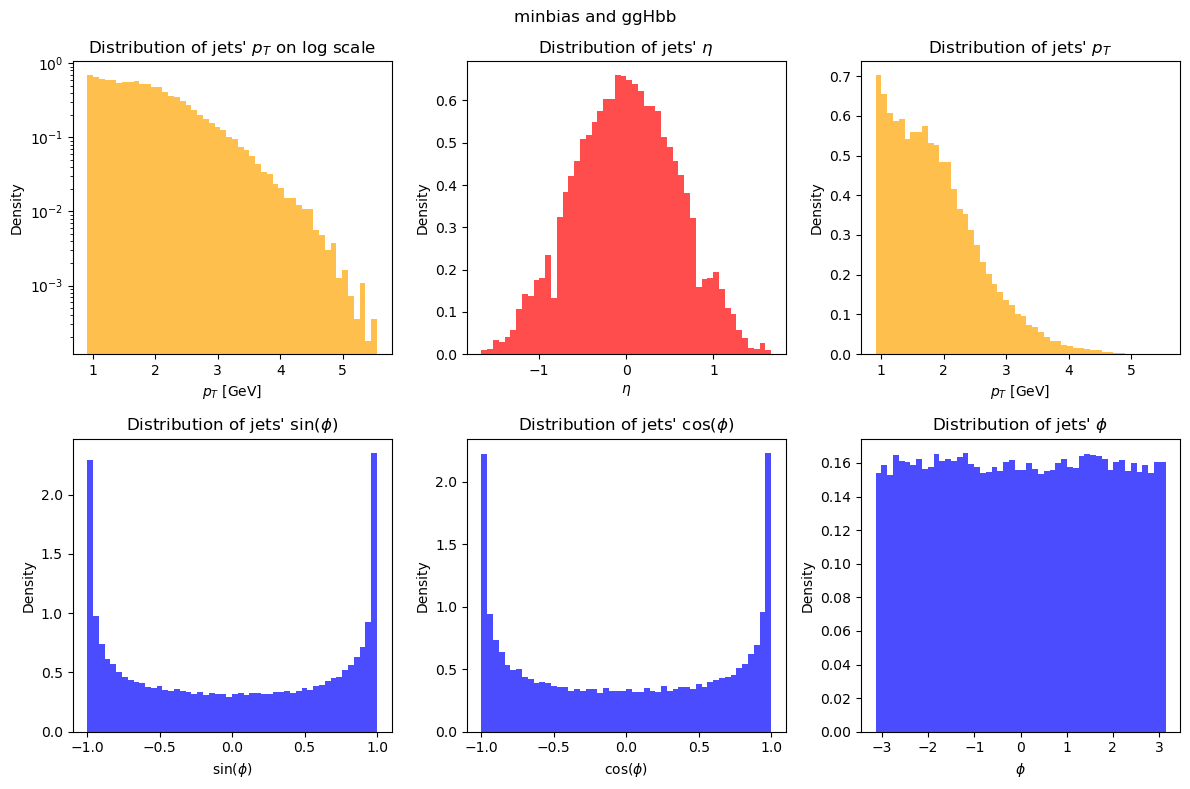

In [160]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

ax[0,0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0,0].set_xlabel(r"$p_T$ [GeV]")
ax[0,0].set_ylabel("Density")
ax[0,0].set_title(r"Distribution of jets' $p_T$ on log scale")

ax[0,1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[0,1].set_xlabel(r"$\eta$")
ax[0,1].set_ylabel("Density")
ax[0,1].set_title(r"Distribution of jets' $\eta$")

ax[0,2].hist(pt, bins=50, density=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0,2].set_xlabel(r"$p_T$ [GeV]")
ax[0,2].set_ylabel("Density")
ax[0,2].set_title(r"Distribution of jets' $p_T$")

ax[1,0].hist(phi_sin, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,0].set_xlabel(r"$\sin(\phi)$")
ax[1,0].set_ylabel("Density")
ax[1,0].set_title(r"Distribution of jets' $\sin(\phi)$")

ax[1,1].hist(phi_cos, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,1].set_xlabel(r"$\cos(\phi)$")
ax[1,1].set_ylabel("Density")
ax[1,1].set_title(r"Distribution of jets' $\cos(\phi)$")

ax[1,2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[1,2].set_xlabel(r"$\phi$")
ax[1,2].set_ylabel("Density")
ax[1,2].set_title(r"Distribution of jets' $\phi$")

plt.suptitle("minbias and ggHbb")
plt.tight_layout()
plt.show()